<a href="https://colab.research.google.com/github/pragyasslwsb/SCT_WD_2/blob/main/Online_Food_Delivery_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split

In [8]:
df=pd.read_csv('online food delivery dataset (1).csv')

In [9]:
print(df.head())

   Age  Gender Marital Status  ... Output   Feedback Unnamed: 13
0   20  Female         Single  ...    Yes   Positive         Yes
1   24  Female         Single  ...    Yes   Positive         Yes
2   22    Male         Single  ...    Yes  Negative          Yes
3   22  Female         Single  ...    Yes   Positive         Yes
4   22    Male         Single  ...    Yes   Positive         Yes

[5 rows x 14 columns]


In [10]:
print(df.shape)

(388, 14)


In [12]:
print(df.columns)

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback',
       'Unnamed: 13'],
      dtype='object')


In [14]:
print(df['Educational Qualifications'].value_counts())

Educational Qualifications
Graduate         177
Post Graduate    174
Ph.D              23
School            12
Uneducated         2
Name: count, dtype: int64


/tmp/ipykernel_7587/659674244.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Educational Qualifications',data=df,palette='Set2')


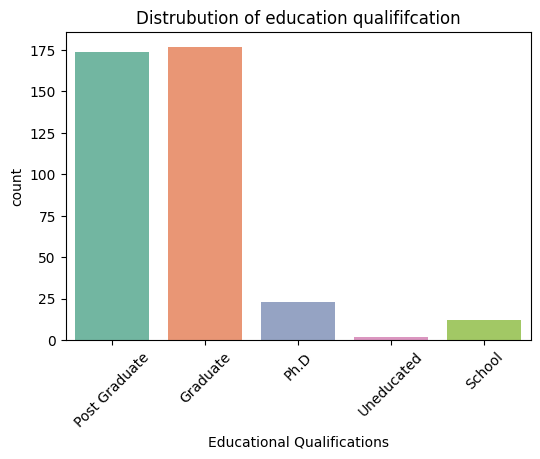

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Educational Qualifications',data=df,palette='Set2')
plt.title('Distrubution of education qualififcation')
plt.xticks(rotation=45)
plt.show()


In [18]:
print('----Missin values in eachcolumn----')
print(df.isnull().sum())
print(df['Output'].value_counts())

----Missin values in eachcolumn----
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64
Output
Yes    301
No      87
Name: count, dtype: int64


In [19]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [20]:
df_encoded.shape

(388, 24)

In [21]:
df_encoded.head(2)

,Age,Family size,latitude,longitude,Pin code,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,Occupation_Student,Monthly Income_25001 to 50000,Monthly Income_Below Rs.10000,Monthly Income_More than 50000,Monthly Income_No Income,Educational Qualifications_Ph.D,Educational Qualifications_Post Graduate,Educational Qualifications_School,Educational Qualifications_Uneducated,Customer Type_New,Customer Type_Regular,Output_Yes,Feedback_Positive,Unnamed: 13_Yes
0,20,4,12.9766,77.5993,560001,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,False,True,True,True
1,24,3,12.9770,77.5773,560009,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,True,True,True


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split

In [23]:
df['Output'].unique()

array(['Yes', 'No'], dtype=object)

In [25]:
y=df['Output'].apply(lambda val: 1 if val in ['Yes','Positive',1]else 0)

In [26]:
x= df.drop(columns=['Output'])

In [28]:
x_encoded =pd.get_dummies(x,drop_first=True)

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x_encoded,y,test_size=0.2,random_state=42)

In [30]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [31]:
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)

In [32]:
print(f'\nModel.Accuracy:{accuracy*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test,y_pred))


Model.Accuracy:100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        66

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split


In [35]:
y=df['Output'].apply(lambda val:1 if val in['Yes','Positive',1,'Active']else 0)

In [37]:
x_train,x_test,y_train,y_test=train_test_split(x_encoded,y,test_size=0.2,random_state=42)

In [38]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [39]:
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)

In [40]:
print(f'Model Accuracy:{accuracy*100:2f}%\n')
print('Classification Report:')
print(classification_report(y_test,y_pred))

Model Accuracy:100.000000%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        66

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
x=df.drop(columns=['Output'])

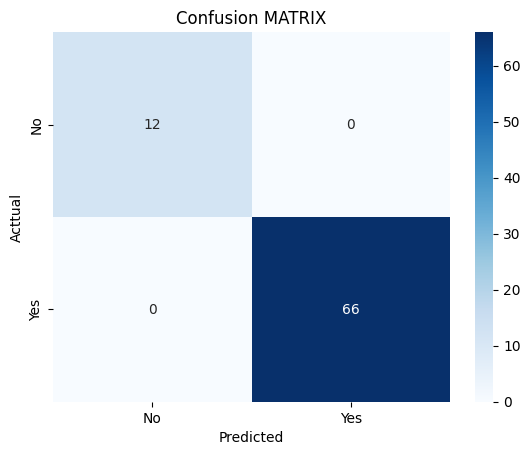

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
#plt.figure(figsize(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No','Yes'],yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Acttual')
plt.title('Confusion MATRIX')
plt.show()

In [48]:
print(f"Final Model Accuracy:{accuracy*100:.2f}%")

Final Model Accuracy:100.00%
